# Voltage Self-Loop Gradient Analysis

This notebook analyzes the exact surrogate-gradient trick used in [v1_model_utils/models.py](../v1_model_utils/models.py):

- forward update keeps the membrane self-loop intact,
- backward update scales the direct membrane gradient by `1 - voltage_gradient_dampening`,
- `dv = 1.0` therefore removes the *direct* voltage self-loop gradient entirely.

The questions are:

1. What does `dv` do mathematically?
2. When is removing the voltage self-loop gradient helpful?
3. When does it destroy necessary temporal credit assignment?

The notebook uses two deliberately small toy systems:

- a linear recurrent state to isolate the direct temporal credit path,
- a one-neuron LIF-style toy with detached reset and surrogate derivatives to study optimization stability.

These toy systems do **not** replace the full V1 model, but they make the effect of the voltage-gradient dampening explicit.

## Repo Semantics

The repo implements the straight-through dampening helper

```python
straight_through_dampen(v, dv)
```

with these semantics:

- forward pass: `straight_through_dampen(v, dv) = v`
- backward pass: `d/dv = 1 - dv`

For the simplified membrane update

```python
v_t = beta * dampen(v_{t-1}, dv) + c_t - stop_gradient(z_{t-1})
```

the direct temporal Jacobian through the membrane state becomes

```text
∂v_t / ∂v_{t-1} = beta * (1 - dv)
```

So:

- `dv = 0.0` keeps the full direct membrane credit path,
- `dv = 0.5` keeps half of it,
- `dv = 1.0` removes it completely.

Importantly, `dv = 1.0` does **not** remove the forward membrane carry. It only truncates the direct backward path through that carry.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60.0, 60.0)))


def bce_with_logits(logits, labels):
    return np.logaddexp(0.0, logits) - labels * logits


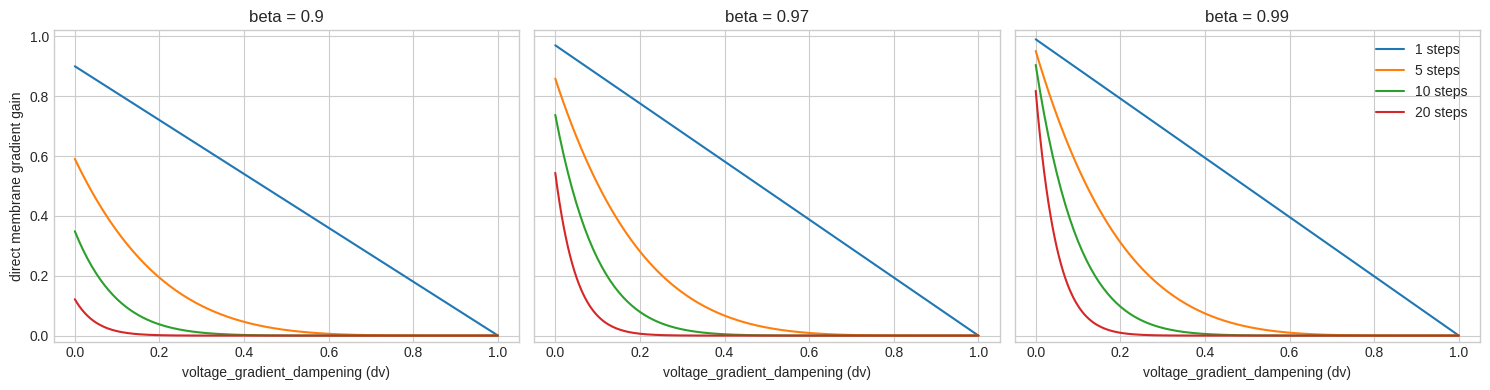

beta   dv    gain after 10 steps   gain after 30 steps
0.90  0.0      3.874205e-01      4.710129e-02
0.90  0.3      1.563381e-02      1.516617e-06
0.90  0.5      7.566806e-04      8.773298e-11
0.90  0.8      1.983593e-07      2.528731e-22
0.90  1.0      0.000000e+00      0.000000e+00
0.97  0.0      7.602311e-01      4.134093e-01
0.97  0.3      3.067807e-02      1.331139e-05
0.97  0.5      1.484826e-03      7.700349e-10
0.97  0.8      3.892383e-07      2.219475e-21
0.97  1.0      0.000000e+00      0.000000e+00
0.99  0.0      9.135172e-01      7.471721e-01
0.99  0.3      3.686372e-02      2.405824e-05
0.99  0.5      1.784213e-03      1.391716e-09
0.99  0.8      4.677208e-07      4.011350e-21
0.99  1.0      0.000000e+00      0.000000e+00


In [2]:
def direct_voltage_gain(beta, dv, steps):
    return (beta * (1.0 - dv)) ** steps

betas = [0.90, 0.97, 0.99]
dv_values = np.linspace(0.0, 1.0, 201)
steps = [1, 5, 10, 20]

fig, axes = plt.subplots(1, len(betas), figsize=(15, 4), sharey=True)
for ax, beta in zip(axes, betas):
    for horizon in steps:
        ax.plot(dv_values, direct_voltage_gain(beta, dv_values, horizon), label=f'{horizon} steps')
    ax.set_title(f'beta = {beta}')
    ax.set_xlabel('voltage_gradient_dampening (dv)')
    ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel('direct membrane gradient gain')
axes[-1].legend(loc='upper right')
plt.tight_layout()
plt.show()

summary_rows = []
for beta in betas:
    for dv in [0.0, 0.3, 0.5, 0.8, 1.0]:
        summary_rows.append((beta, dv, direct_voltage_gain(beta, dv, 9), direct_voltage_gain(beta, dv, 29)))

print('beta   dv    gain after 10 steps   gain after 30 steps')
for beta, dv, g10, g30 in summary_rows:
    print(f'{beta:4.2f}  {dv:3.1f}      {g10:12.6e}      {g30:12.6e}')


## Toy A: Delayed-Memory Task

This toy isolates the **direct** temporal credit path.

Forward model:

```text
h_t = beta * h_{t-1} + w * x_t
```

Backward model:

```text
∂h_t / ∂h_{t-1} := beta * (1 - dv)
```

The task is intentionally extreme:

- only the **first** input pulse contains label information,
- the loss is applied only to the **final** state.

In this setup, the direct membrane self-loop is the only temporal credit path. Therefore `dv = 1.0` should remove learning almost exactly.

Delayed-memory task at initialization
dv    loss       |grad_w|
0.0  0.693147  3.047422e-14
0.3  0.693147  5.456002e-169
0.5  0.693147  5.688095e-315
0.8  0.693147  0.000000e+00
1.0  0.693147  0.000000e+00


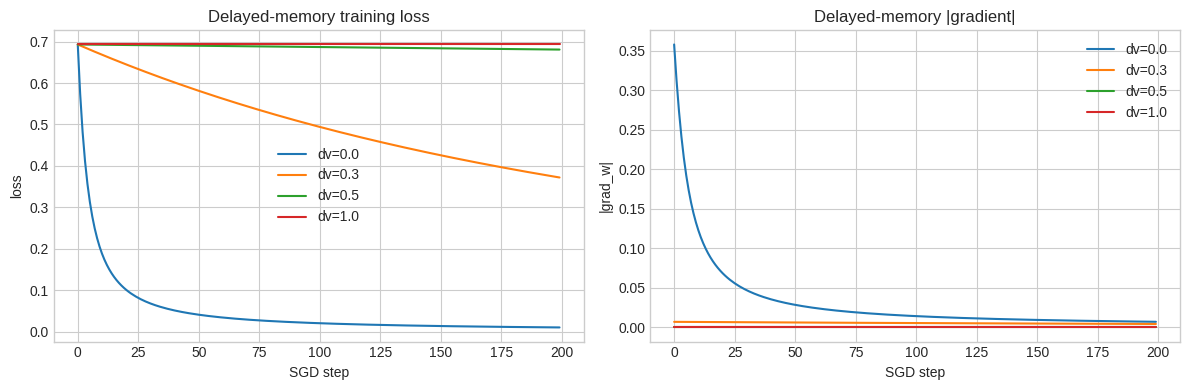

Final delayed-memory metrics
dv    final w    mean last-20 loss    mean last-20 |grad|
0.0     6.4345            0.010546        7.503870e-03
0.3     1.1185            0.381603        4.486744e-03
0.5     0.0347            0.681450        1.725794e-04
1.0     0.0000            0.693147        0.000000e+00


In [8]:
rng = np.random.default_rng(7)


def final_state_linear(x, w, beta):
    seq_len = x.shape[1]
    forward_powers = beta ** np.arange(seq_len - 1, -1, -1)
    return w * (x * forward_powers[None, :]).sum(axis=1)


def delayed_memory_batch(batch_size, seq_len, signal=1.0):
    labels = rng.integers(0, 2, size=(batch_size, 1)).astype(np.float64)
    signed = 2.0 * labels - 1.0
    x = np.zeros((batch_size, seq_len), dtype=np.float64)
    x[:, 0] = signal * signed[:, 0]
    return x, labels


def delayed_memory_loss_and_grad(x, y, w, beta, dv):
    logits = final_state_linear(x, w, beta)
    loss = np.mean(bce_with_logits(logits, y[:, 0]))
    backward_powers = (beta * (1.0 - dv)) ** np.arange(x.shape[1] - 1, -1, -1)
    dlogit_dw_surrogate = (x * backward_powers[None, :]).sum(axis=1)
    grad = np.mean((sigmoid(logits) - y[:, 0]) * dlogit_dw_surrogate)
    return loss, grad


def train_delayed_memory(dv, beta=0.97, seq_len=12, lr=1.0, steps=200, batch_size=256):
    w = 0.0
    losses = []
    grads = []
    for _ in range(steps):
        x, y = delayed_memory_batch(batch_size, seq_len)
        loss, grad = delayed_memory_loss_and_grad(x, y, w, beta, dv)
        w -= lr * grad
        losses.append(loss)
        grads.append(grad)
    return w, np.array(losses), np.array(grads)

initial_gradients = []
for dv in [0.0, 0.3, 0.5, 0.8, 1.0]:
    x0, y0 = delayed_memory_batch(1024, 1000)
    loss0, grad0 = delayed_memory_loss_and_grad(x0, y0, w=0.0, beta=0.97, dv=dv)
    initial_gradients.append((dv, loss0, abs(grad0)))

print('Delayed-memory task at initialization')
print('dv    loss       |grad_w|')
for dv, loss0, grad0 in initial_gradients:
    print(f'{dv:3.1f}  {loss0:8.6f}  {grad0:10.6e}')

histories = {}
for dv in [0.0, 0.3, 0.5, 1.0]:
    w, losses, grads = train_delayed_memory(dv)
    histories[dv] = {'w': w, 'losses': losses, 'grads': grads}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for dv, data in histories.items():
    axes[0].plot(data['losses'], label=f'dv={dv}')
    axes[1].plot(np.abs(data['grads']), label=f'dv={dv}')
axes[0].set_title('Delayed-memory training loss')
axes[0].set_xlabel('SGD step')
axes[0].set_ylabel('loss')
axes[1].set_title('Delayed-memory |gradient|')
axes[1].set_xlabel('SGD step')
axes[1].set_ylabel('|grad_w|')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

print('Final delayed-memory metrics')
print('dv    final w    mean last-20 loss    mean last-20 |grad|')
for dv, data in histories.items():
    print(
        f"{dv:3.1f}  {data['w']:9.4f}  {data['losses'][-20:].mean():18.6f}  {np.abs(data['grads'][-20:]).mean():18.6e}"
    )


**Interpretation of Toy A**

This is the cleanest counterexample to `dv = 1.0` as a universal default.

When the late loss depends on an early signal **only through membrane carry**, the direct membrane self-loop is the only credit-assignment path. Removing that path makes the surrogate gradient exactly zero. In that case, `dv = 1.0` is not just aggressive regularization; it removes the information needed for learning.

## Toy B: LIF-Style Rate Control with Detached Reset

The second toy is closer to the repo's situation:

- hard threshold spikes,
- detached reset in the backward pass,
- surrogate derivative for the spike function,
- optional dampening of the direct membrane self-loop gradient.

The task is simple rate control under constant noisy drive: make the neuron fire at a target average rate.

This task provides supervision at *many* time steps through the spike-count loss, so learning does not rely on the membrane self-loop as the only temporal path. In this regime, dampening the voltage gradient can act as an optimization stabilizer.

Rate-control task gradient statistics at initialization
dv    loss       mean |grad_w|    std(grad_w)    mean |dL/du|
0.0  0.248716      13.578001      0.098033       0.301877
0.3  0.248953       1.902987      0.012700       0.043111
0.5  0.249000       1.174826      0.008705       0.026924
0.8  0.248862       0.737556      0.004840       0.017195
1.0  0.248590       0.588511      0.004667       0.013864


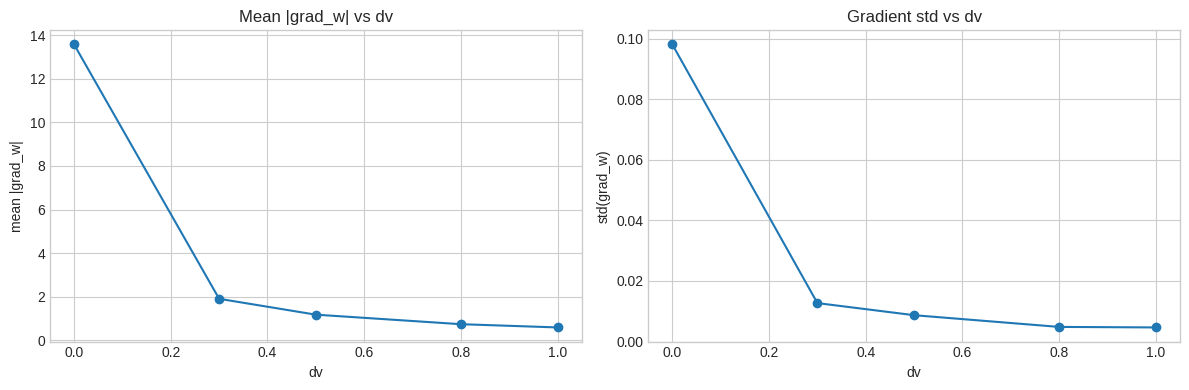

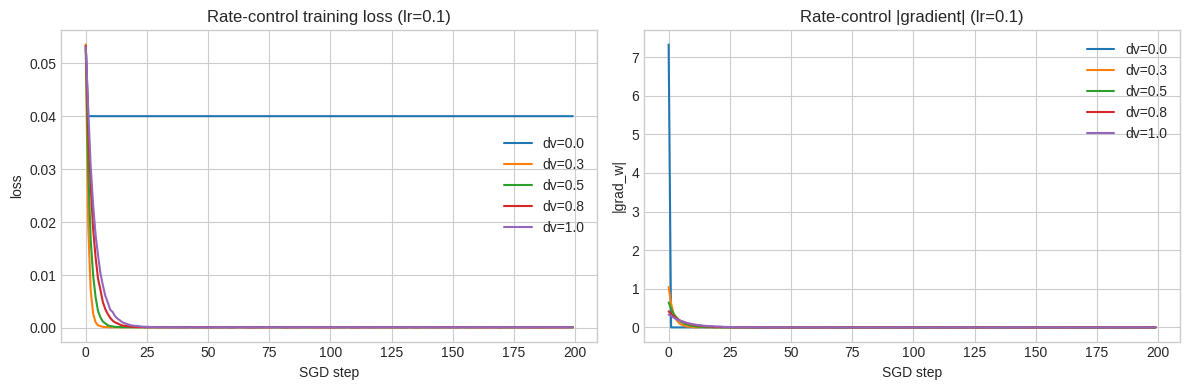

Final rate-control metrics at lr = 0.1
dv    final w    mean last-20 loss    mean last-20 |grad|
0.0    -0.2286            0.040000        2.143295e-04
0.3     0.2404            0.000134        2.446863e-03
0.5     0.2401            0.000133        1.709088e-03
0.8     0.2404            0.000131        1.120674e-03
1.0     0.2400            0.000131        8.326578e-04


In [4]:
def surrogate_derivative(u, theta=1.0, alpha=5.0):
    s = sigmoid(alpha * (u - theta))
    return alpha * s * (1.0 - s)


def lif_forward(x, w, beta=0.99, theta=1.0):
    batch_size, seq_len = x.shape
    u = np.zeros(batch_size, dtype=np.float64)
    z_prev = np.zeros(batch_size, dtype=np.float64)
    us = np.zeros((batch_size, seq_len), dtype=np.float64)
    zs = np.zeros((batch_size, seq_len), dtype=np.float64)

    for t in range(seq_len):
        u = beta * u + w * x[:, t] - z_prev
        z = (u >= theta).astype(np.float64)
        us[:, t] = u
        zs[:, t] = z
        z_prev = z

    return us, zs


def rate_task_batch(batch_size, seq_len, target_rate=0.2):
    x = rng.standard_normal((batch_size, seq_len)) * 0.3 + 0.9
    target = np.full((batch_size, 1), target_rate, dtype=np.float64)
    return x, target


def spike_count_loss_and_grad(x, target, w, beta=0.99, dv=0.0, theta=1.0, alpha=5.0):
    us, zs = lif_forward(x, w, beta=beta, theta=theta)
    pred_rate = zs.mean(axis=1)
    loss = np.mean((pred_rate - target[:, 0]) ** 2)

    dloss_dpred = 2.0 * (pred_rate - target[:, 0])
    dloss_dz = np.repeat((dloss_dpred / x.shape[1])[:, None], x.shape[1], axis=1)
    spike_surrogate = surrogate_derivative(us, theta=theta, alpha=alpha)

    backward_gain = beta * (1.0 - dv)
    dloss_du = np.zeros_like(us)
    future = np.zeros(x.shape[0], dtype=np.float64)
    for t in range(x.shape[1] - 1, -1, -1):
        future = dloss_dz[:, t] * spike_surrogate[:, t] + backward_gain * future
        dloss_du[:, t] = future

    grad = np.mean(np.sum(dloss_du * x, axis=1))
    return loss, grad, pred_rate.mean(), np.mean(np.abs(dloss_du))


def gradient_stats_rate_task(dv, beta=0.99, seq_len=50, w=0.8, batches=128, batch_size=256):
    grads = []
    du_means = []
    losses = []
    for _ in range(batches):
        x, target = rate_task_batch(batch_size, seq_len)
        loss, grad, _, du_mean = spike_count_loss_and_grad(x, target, w=w, beta=beta, dv=dv)
        grads.append(grad)
        du_means.append(du_mean)
        losses.append(loss)
    grads = np.asarray(grads)
    return {
        'loss': float(np.mean(losses)),
        'grad_abs_mean': float(np.mean(np.abs(grads))),
        'grad_std': float(np.std(grads)),
        'du_abs_mean': float(np.mean(du_means)),
    }


def train_rate_task(dv, lr, beta=0.99, seq_len=50, steps=200, batch_size=256):
    w = 0.5
    losses = []
    grads = []
    for _ in range(steps):
        x, target = rate_task_batch(batch_size, seq_len)
        loss, grad, _, _ = spike_count_loss_and_grad(x, target, w=w, beta=beta, dv=dv)
        w -= lr * grad
        losses.append(loss)
        grads.append(grad)
    return w, np.asarray(losses), np.asarray(grads)

rate_gradient_metrics = []
for dv in [0.0, 0.3, 0.5, 0.8, 1.0]:
    stats = gradient_stats_rate_task(dv)
    rate_gradient_metrics.append((dv, stats['loss'], stats['grad_abs_mean'], stats['grad_std'], stats['du_abs_mean']))

print('Rate-control task gradient statistics at initialization')
print('dv    loss       mean |grad_w|    std(grad_w)    mean |dL/du|')
for dv, loss, grad_mean, grad_std, du_mean in rate_gradient_metrics:
    print(f'{dv:3.1f}  {loss:8.6f}  {grad_mean:13.6f}  {grad_std:12.6f}  {du_mean:13.6f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot([row[0] for row in rate_gradient_metrics], [row[2] for row in rate_gradient_metrics], marker='o')
ax[0].set_title('Mean |grad_w| vs dv')
ax[0].set_xlabel('dv')
ax[0].set_ylabel('mean |grad_w|')
ax[1].plot([row[0] for row in rate_gradient_metrics], [row[3] for row in rate_gradient_metrics], marker='o')
ax[1].set_title('Gradient std vs dv')
ax[1].set_xlabel('dv')
ax[1].set_ylabel('std(grad_w)')
plt.tight_layout()
plt.show()

rate_histories = {}
for dv in [0.0, 0.3, 0.5, 0.8, 1.0]:
    w, losses, grads = train_rate_task(dv=dv, lr=0.1)
    rate_histories[dv] = {'w': w, 'losses': losses, 'grads': grads}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for dv, data in rate_histories.items():
    axes[0].plot(data['losses'], label=f'dv={dv}')
    axes[1].plot(np.abs(data['grads']), label=f'dv={dv}')
axes[0].set_title('Rate-control training loss (lr=0.1)')
axes[0].set_xlabel('SGD step')
axes[0].set_ylabel('loss')
axes[1].set_title('Rate-control |gradient| (lr=0.1)')
axes[1].set_xlabel('SGD step')
axes[1].set_ylabel('|grad_w|')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

print('Final rate-control metrics at lr = 0.1')
print('dv    final w    mean last-20 loss    mean last-20 |grad|')
for dv, data in rate_histories.items():
    print(
        f"{dv:3.1f}  {data['w']:9.4f}  {data['losses'][-20:].mean():18.6f}  {np.abs(data['grads'][-20:]).mean():18.6e}"
    )


**Interpretation of Toy B**

This toy shows the opposite regime.

Here the loss is spread over time through spike-count supervision, so learning does **not** depend on the direct membrane self-loop alone. In that case:

- low `dv` can create very large membrane adjoints and noisy gradients,
- moderate or large `dv` reduces those gradients sharply,
- `dv = 1.0` can still learn because useful local gradients remain through the current step and the spike surrogate.

This is the regime in which removing the direct voltage self-loop gradient can improve optimization stability and allow larger effective learning rates.

## Literature Notes

What the literature suggests is **not** that removing the voltage self-loop gradient is always correct, but that modifying reset/membrane temporal gradients is often useful and highly task-dependent.

- Neftci, Mostafa, and Zenke (2019), *Surrogate Gradient Learning in Spiking Neural Networks*: frames SNN training as a recurrent optimization problem and highlights that temporal dynamics and surrogate choices are central to trainability.
- Zenke and Vogels (2021), *The Remarkable Robustness of Surrogate Gradient Learning for Instilling Complex Function in Spiking Neural Networks*: reports that surrogate learning is robust, but that the scale of the temporal/spike surrogate matters; the reset path acts like an implicit recurrence that can destabilize learning when not handled carefully.
- Gygax and Zenke (2024/2025), *Elucidating the theoretical underpinnings of surrogate gradient learning in spiking neural networks*: explicitly notes that most prior surrogate-gradient work backpropagates through the spike surrogate but **not** through reset, and shows that this choice changes the bias of the gradient field.
- Bauer et al. (2022), *EXODUS: Stable and Efficient Training of Spiking Neural Networks*: argues that one older training rule became numerically unstable because it ignored the reset mechanism in the gradient; accounting for reset exactly recovered stable gradients without ad-hoc scaling.
- Fang et al. (2023), *Parallel Spiking Neurons with High Efficiency and Ability to Learn Long-term Dependencies*: studies removing reset from the **forward dynamics** to obtain parallel spiking neurons. This is a stronger intervention than `dv = 1.0`, and their results show that removing reset changes the inductive bias substantially rather than being a universally free win.

Taken together, the literature supports this interpretation:

- truncating or detaching temporal spike/reset paths is a reasonable **optimization bias**,
- it can help when exact or less-truncated temporal gradients are unstable or mostly nuisance,
- it can hurt when the removed path is the only meaningful long-range credit path.

## Practical Conclusion for `models.py`

Completely removing the direct voltage self-loop gradient (`dv = 1.0`) is **not** universally correct, but it can be a perfectly sensible surrogate for learning when all of the following are true:

- the direct membrane path is numerically problematic,
- the task has other usable credit-assignment routes,
- losses are distributed over time or close to the readout,
- recurrent synapses / current states / spike surrogates already carry enough temporal information.

It is risky when:

- long-delay credit depends mainly on membrane carry,
- the neuron must remember an early event with little other recurrent structure,
- you care about exact temporal credit through the membrane state itself.

For the current V1 model this means:

- `dv = 1.0` is best understood as **full truncation of the direct membrane credit path**, not as removing forward memory,
- if it works well empirically, that is evidence that the full model has enough alternative temporal paths,
- if a task becomes more delay-dependent, `dv = 1.0` may become too aggressive.

The most informative next experiment is usually a **joint sweep over `dv` and learning-rate schedule** rather than choosing `dv` in isolation.